# Validación de Estimador de Emisiones CO2 (FCR Model)

Este notebook valida el modelo de cálculo de emisiones basado en el **Fuel Consumption Rate (FCR)** siguiendo el estudio de *Xiao et al. (2012)*.

### Fórmula Principal:
$\rho(Q) = \rho_0 + \frac{\rho^* - \rho_0}{Q_{max}} \cdot Q$

Donde:
- $\rho_0$: Emisión en vacío (kg CO2/km).
- $\rho^*$: Emisión a plena carga (kg CO2/km).
- $Q$: Carga actual del vehículo.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

# INSERCIÓN DEL PROYECTO EN LA POSICIÓN 0 PARA EVITAR COLISIÓN CON PAQUETES GLOBALES 'src'
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from logistic_core.utils.fcr_estimator import FCREmissionEstimator

print("Estimador importado con éxito desde el repositorio local.")

Estimador importado con éxito desde el repositorio local.


## 1. Configuración del Escenario
Configuramos un camión con una emisión de **1.1 kg CO2/km** a plena carga y un factor $\alpha=0.5$ (vacio emite el 50%).

In [2]:
fcr_max = 1.1  # kg CO2/km
estimator = FCREmissionEstimator(fcr_loaded=fcr_max, alpha=0.5)

print(f"FCR Cargado: {estimator.fcr_loaded} kg/km")
print(f"FCR Vacío (estimado): {estimator.fcr_empty} kg/km")

FCR Cargado: 1.1 kg/km
FCR Vacío (estimado): 0.55 kg/km


## 2. Cálculo de Escenario Redondo (Round Trip)
Simulamos un viaje de 350 km (ida cargado, vuelta vacío).

In [3]:
dist = 350
res = estimator.co2_route(distance_km=dist, n_trips=1)

print(f"--- Viaje de {dist} km ---")
print(f"CO2 Ida (Cargado): {res['co2_loaded_t'] * 1000} kg")
print(f"CO2 Vuelta (Vacío): {res['co2_empty_t'] * 1000} kg")
print(f"Total: {res['co2_total_t']} Toneladas")

--- Viaje de 350 km ---
CO2 Ida (Cargado): 390.0 kg
CO2 Vuelta (Vacío): 190.0 kg
Total: 0.58 Toneladas


## 3. Sensibilidad a la Carga Parcial
Visualizamos cómo varía la emisión según el número de pallets que lleva el camión (0 a 33).

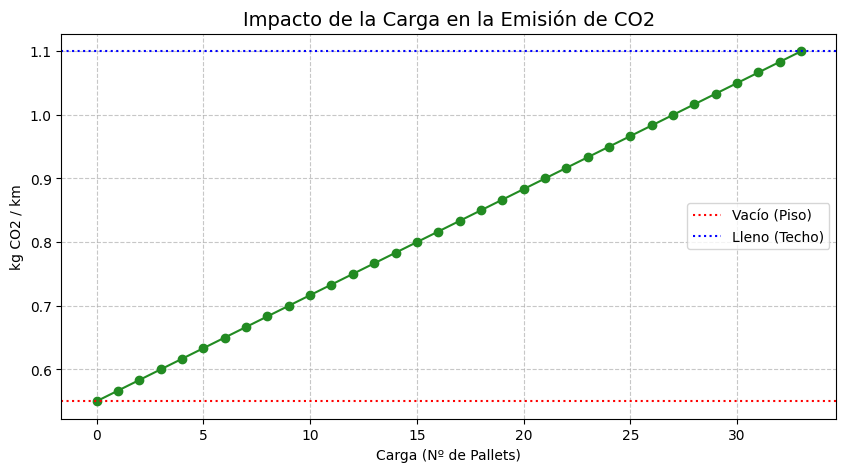

In [4]:
max_p = 33
pallets = np.arange(0, max_p + 1)
emisiones_por_km = [estimator.co2_partial_load(1, p, max_p) for p in pallets]

plt.figure(figsize=(10, 5))
plt.plot(pallets, emisiones_por_km, marker='o', color='forestgreen')
plt.title("Impacto de la Carga en la Emisión de CO2", fontsize=14)
plt.xlabel("Carga (Nº de Pallets)")
plt.ylabel("kg CO2 / km")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=estimator.fcr_empty, color='red', linestyle=':', label='Vacío (Piso)')
plt.axhline(y=estimator.fcr_loaded, color='blue', linestyle=':', label='Lleno (Techo)')
plt.legend()
plt.show()

In [5]:
from logistic_core.utils.fcr_estimator import FCREmissionEstimator

# Inicializamos con tu valor de 1.5 a plena carga
estimator = FCREmissionEstimator(fcr_loaded=1.5, alpha=0.5)

distancia = 100 # km vacio
co2_vacio = estimator.co2_partial_load(distance_km=distancia, current_load=0, max_load=33)

print(f"Emisión total en vacío (100km): {co2_vacio} kg CO2")


Emisión total en vacío (100km): 75.0 kg CO2
